# Exploration — QRIS Synthetic Merchant Generator

Scratchpad for tuning archetype parameters and eyeballing plots.
Real logic lives in `generator.py` — this notebook only imports and visualizes it.

Workflow: tweak params here -> plot -> if it looks right, that's the config worth keeping.
If the logic itself needs to change (not just params), edit `generator.py`, then re-run
the import cell below to pick up the change.

In [6]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from generator import generate_steady_merchant

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Steady archetype — validated baseline (residential, default)

In [7]:
result = generate_steady_merchant(seed=42)
df = result["data"]
print(result["archetype"], result["expected_eligible"], result["params"])
df.head()

steady True {'base_revenue': 500000, 'noise_sigma': 0.08, 'location_type': 'residential'}


,date,revenue
0,2025-01-01,512338.461781
1,2025-01-02,460084.132695
2,2025-01-03,530937.437466
3,2025-01-04,619935.362213
4,2025-01-05,491905.795553


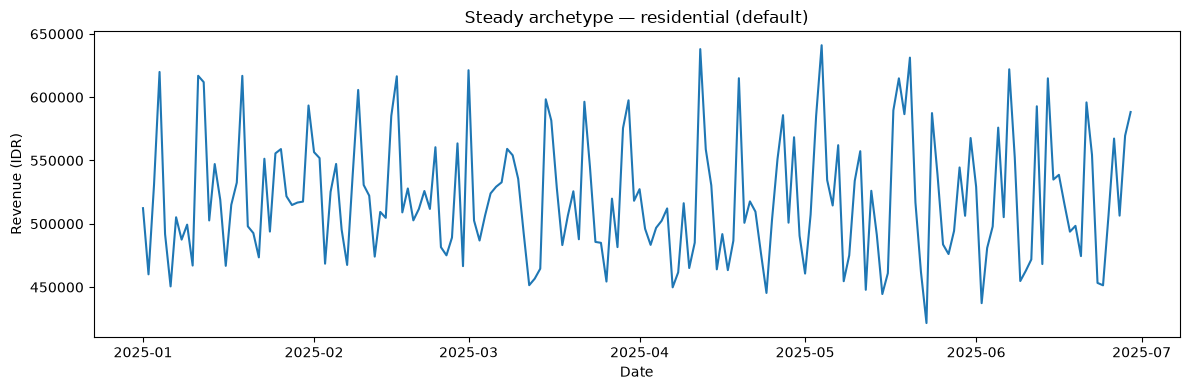

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["revenue"])
ax.set_title("Steady archetype — residential (default)")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (IDR)")
plt.tight_layout()
plt.show()

## location_type comparison — all four side by side

Checklist while eyeballing, per design doc:
- **residential** — mild, regular weekend bumps
- **office_district** — visible weekend *drop*, weekday-high
- **attraction** — weekend peaks, weekday-low
- **market** — flattest of the four, no strong weekly rhythm

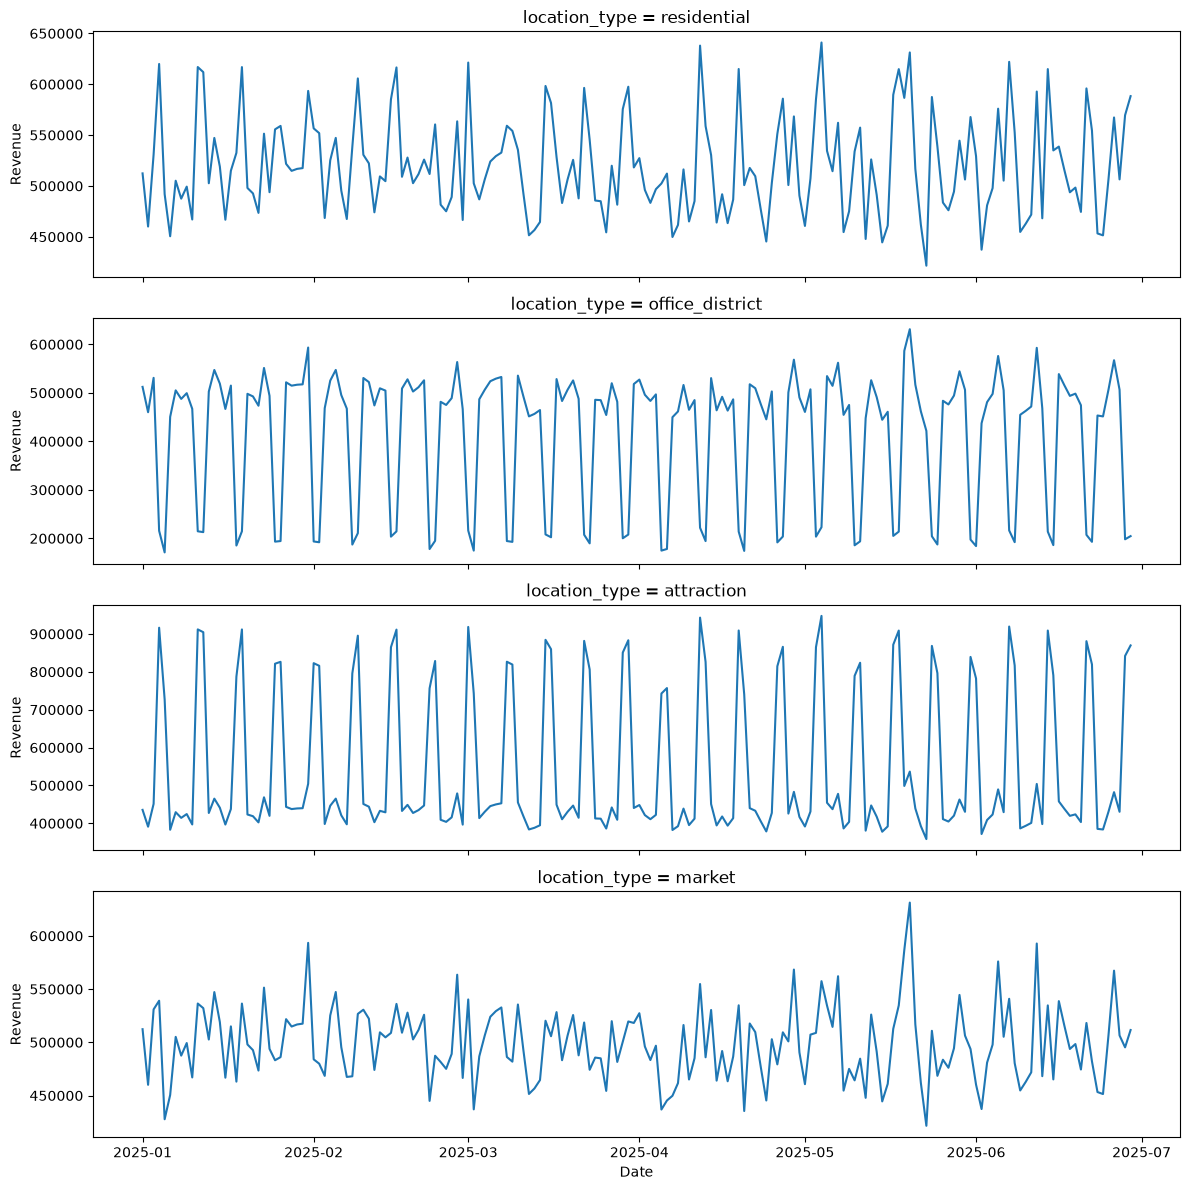

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

location_types = ["residential", "office_district", "attraction", "market"]

for ax, loc in zip(axes, location_types):
    result = generate_steady_merchant(location_type=loc, seed=42)
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"location_type = {loc}")
    ax.set_ylabel("Revenue")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Zoomed view — first 4 weeks, one location_type at a time

180 days compressed into one chart can blur the weekly cycle. Zooming into
4 weeks with markers on each day makes the pattern unambiguous. Change
`loc` below to check a different location_type.

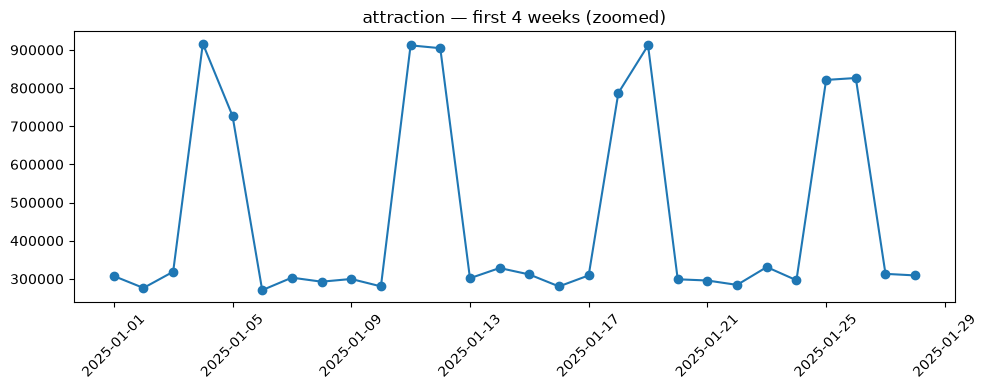

In [14]:
loc = "attraction"  # change to residential / attraction / market to inspect others

result = generate_steady_merchant(location_type=loc, seed=42)
d = result["data"].head(28)  # first 4 weeks only

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d["date"], d["revenue"], marker="o")
ax.set_title(f"{loc} — first 4 weeks (zoomed)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Noise sensitivity sweep (kept from earlier validation)

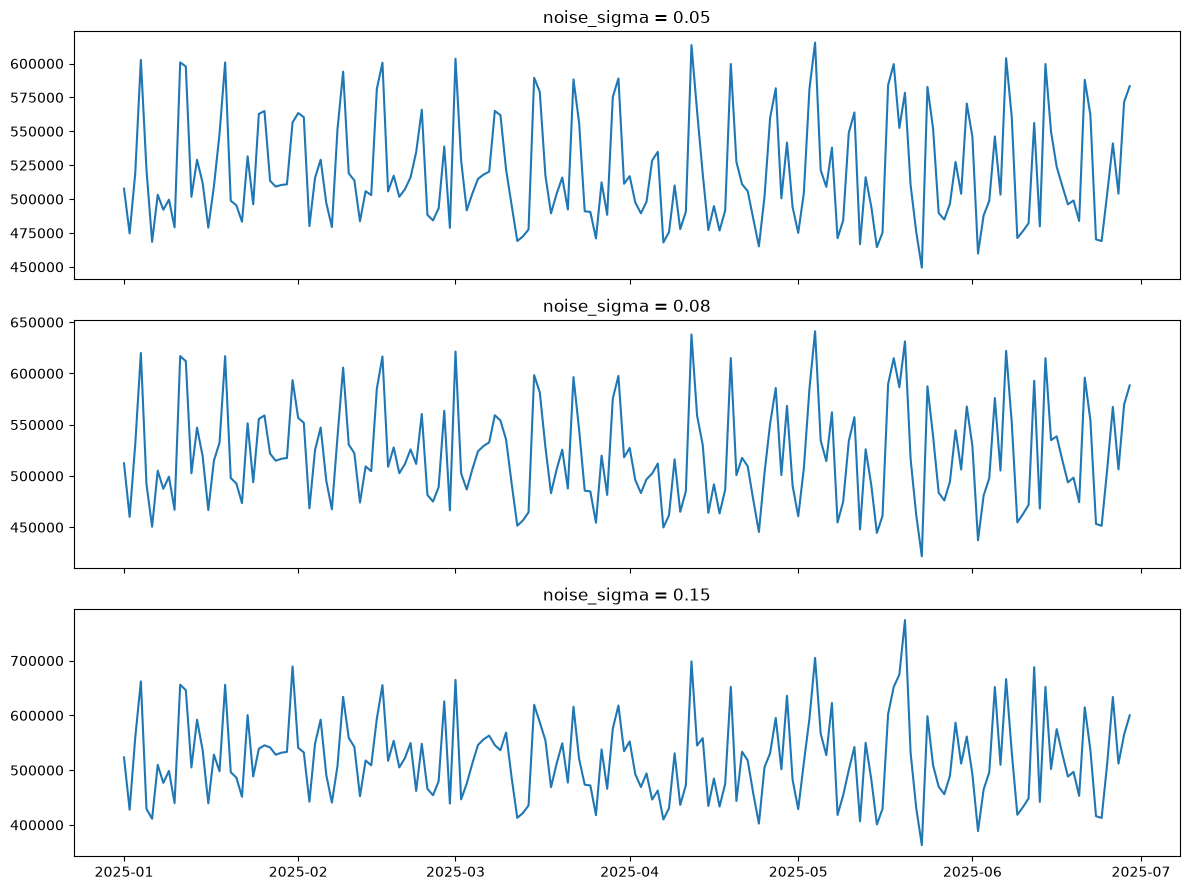

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, sigma in zip(axes, [0.05, 0.08, 0.15]):
    result = generate_steady_merchant(noise_sigma=sigma, seed=42)
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"noise_sigma = {sigma}")

plt.tight_layout()
plt.show()